In [1]:
import torch
print(torch.__version__)

2.7.0+cu126


## Intro to Tensor
### Creating Tensors

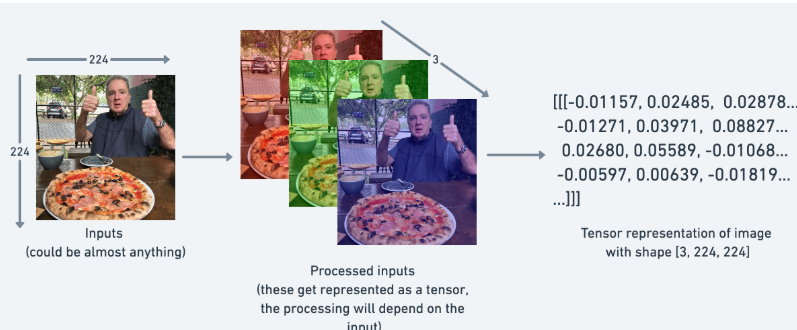

In [2]:
# scaler
scaler = torch.tensor(7.0)
print(scaler)

tensor(7.)


In [3]:
scaler.ndim

0

In [4]:
# torch.Tensor to python int (only works with one-element tensors)
print(scaler.item())

7.0


In [5]:
# Vector
vector = torch.tensor([7, 7, 1])
vector

tensor([7, 7, 1])

In [6]:
# Check the number of dimensions of vector
vector.ndim

1

In [7]:
# Check shape of vector
vector.shape

torch.Size([3])

In [8]:
# Matrix
MATRIX = torch.tensor([[7, 8], 
                       [9, 10]])
MATRIX

tensor([[ 7,  8],
        [ 9, 10]])

In [9]:
MATRIX.ndim

2

In [10]:
MATRIX.shape

torch.Size([2, 2])

In [11]:
# Tensor
TENSOR = torch.tensor([[[1, 2, 3],
                        [4, 5, 6]],
                       [[7, 8, 9],
                        [10, 11, 12]],
                       [[13, 14, 15],
                        [16, 17, 18]]])
TENSOR

tensor([[[ 1,  2,  3],
         [ 4,  5,  6]],

        [[ 7,  8,  9],
         [10, 11, 12]],

        [[13, 14, 15],
         [16, 17, 18]]])

In [12]:
# Check number of dimensions for TENSOR
TENSOR.ndim

3

In [13]:
# Check shape of TENSOR
TENSOR.shape

torch.Size([3, 2, 3])

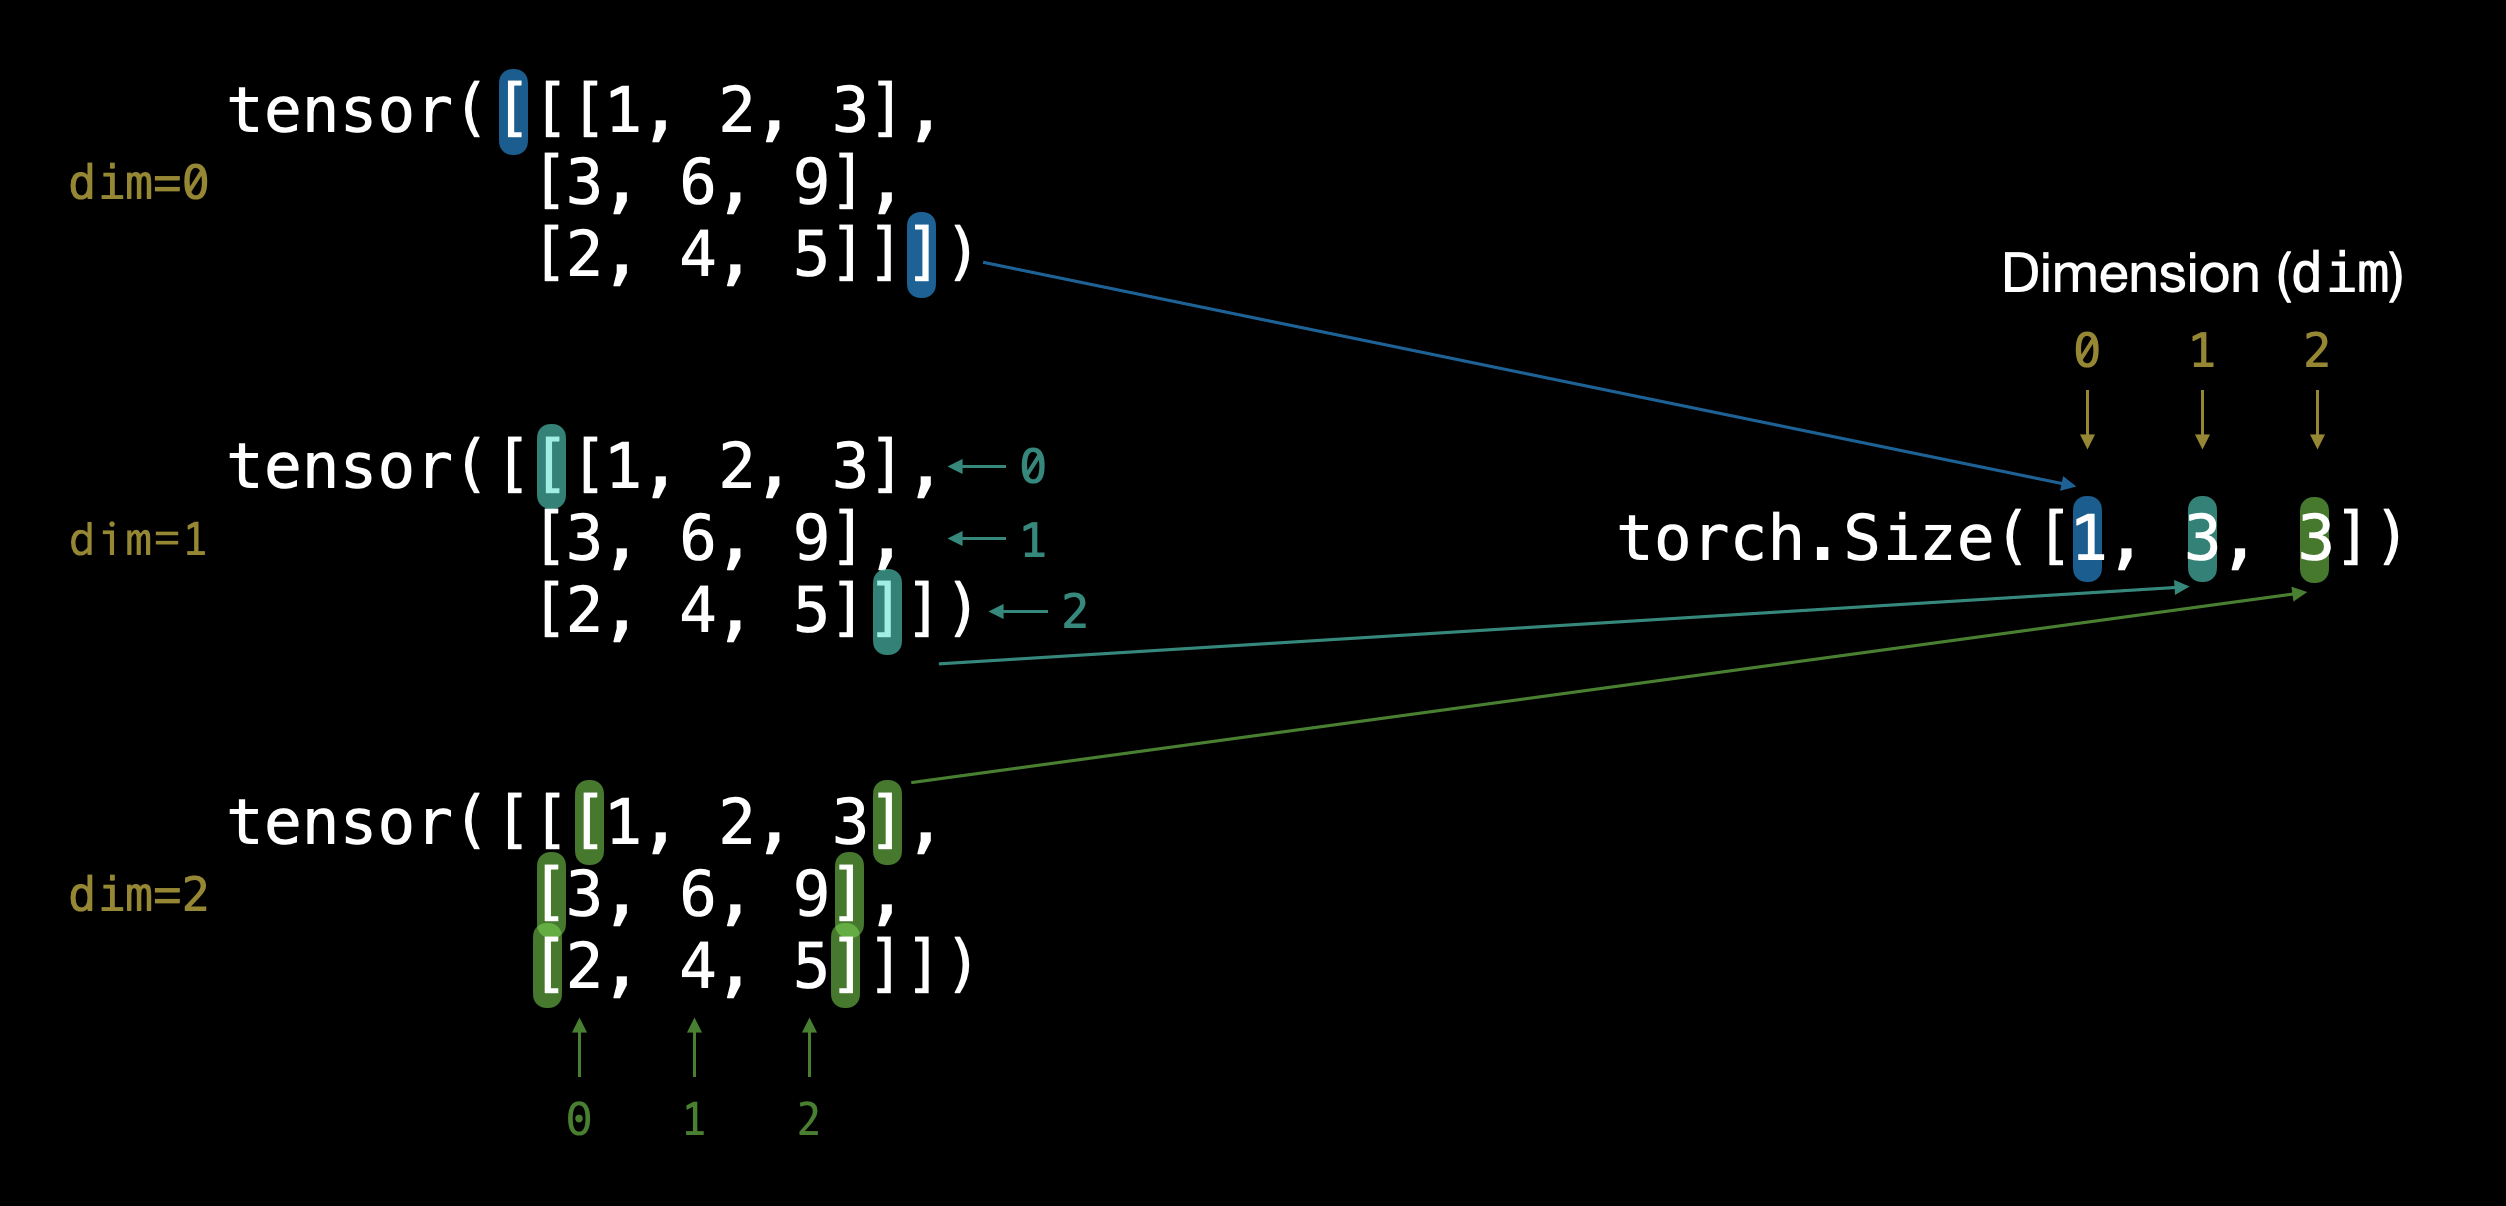

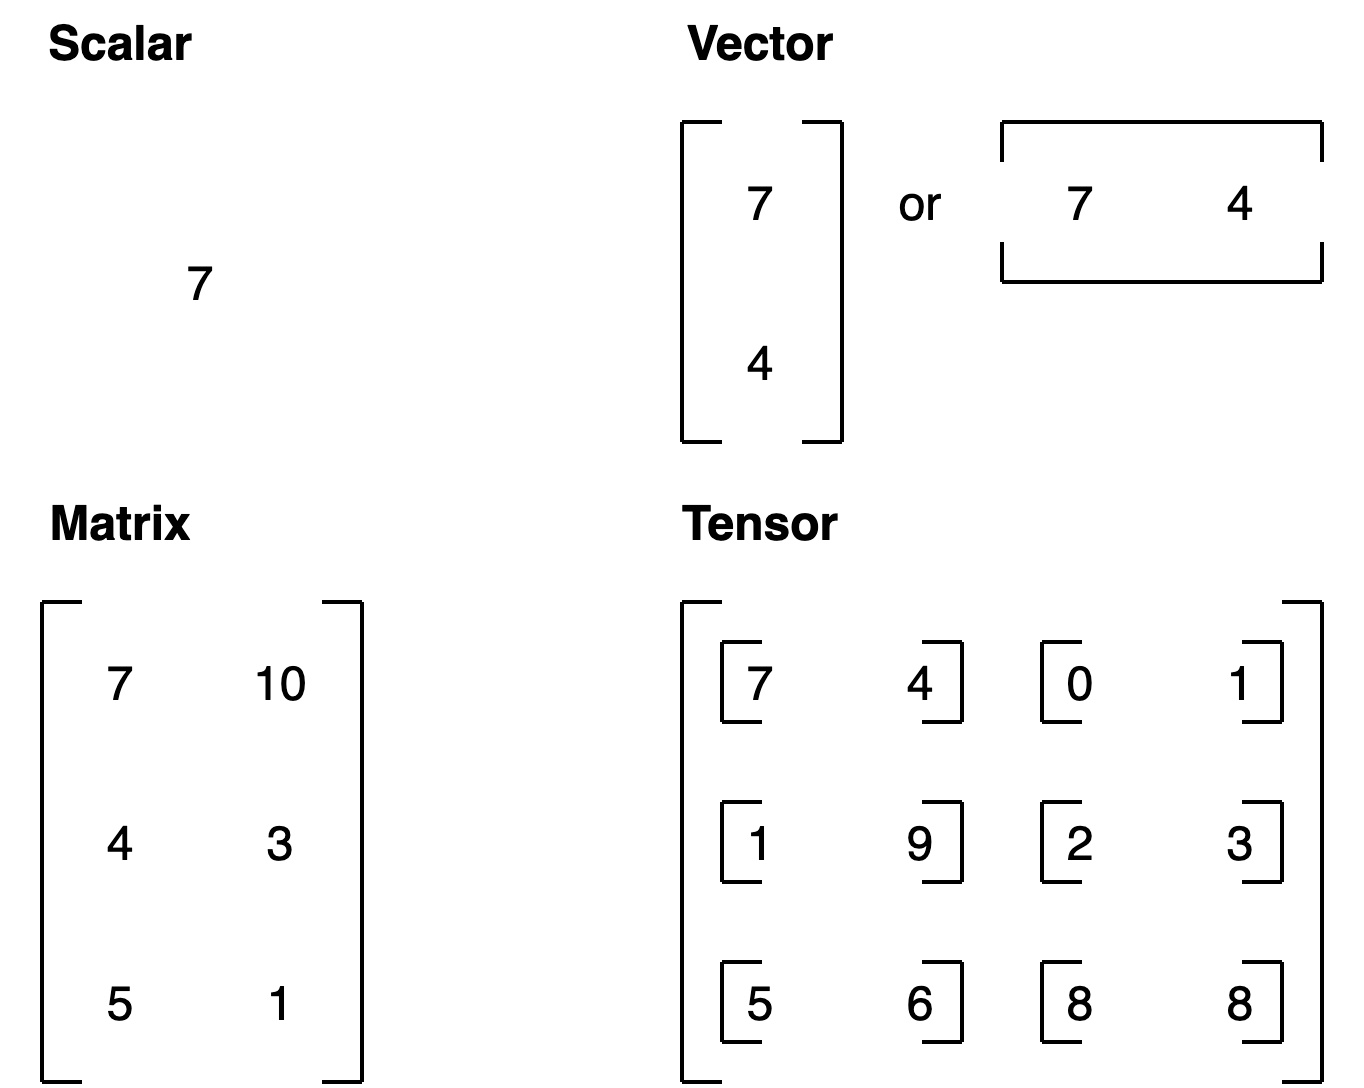

In [14]:
TENSOR[2][1][2]

tensor(18)

## Random Tensros

`Start with random numbers -> look at data -> update random numbers -> look at data -> update random numbers...`

In [15]:
# Create a random tensor of size (3, 4)
X = torch.rand((3, 4))

In [16]:
X, X.dtype

(tensor([[0.4221, 0.0852, 0.9235, 0.1922],
         [0.8898, 0.4730, 0.8683, 0.9214],
         [0.7332, 0.5543, 0.4184, 0.6662]]),
 torch.float32)

In [17]:
# Create a tensor of size (3, 254, 254)
X = torch.rand((3, 254, 254))
X.shape, X.ndim

(torch.Size([3, 254, 254]), 3)

## Zeros and Ones

In [18]:
# Create a tensor with all Zeroes
X = torch.zeros((2, 3))
X, X.dtype

(tensor([[0., 0., 0.],
         [0., 0., 0.]]),
 torch.float32)

In [19]:
# Create a tensor with all Ones
ones = torch.ones((2, 3))
ones, ones.dtype

(tensor([[1., 1., 1.],
         [1., 1., 1.]]),
 torch.float32)

## Creating a range and tensors like

### Creating Range Tensors with `torch.arange()`

**Parameters:**
* `start`: Beginning of the range (e.g., 0)
* `end`: End of the range (e.g., 10) 
* `step`: Interval between values (e.g., 1)

The `torch.arange()` function creates a 1-dimensional tensor containing evenly spaced values within a specified range.

In [20]:
# Create a range of values
range_tensor = torch.arange(0, 9)
range_tensor

tensor([0, 1, 2, 3, 4, 5, 6, 7, 8])

In [21]:
# For example, a tensor of all zeros with the same shape as a previous tensor.
zeros_like = torch.zeros_like(range_tensor) # will have the same shape as range_tensor
zeros_like

tensor([0, 0, 0, 0, 0, 0, 0, 0, 0])

In [22]:
zeros_like.shape

torch.Size([9])

### Tensor datatypes

In [23]:
# Default datatype for tensors is float32
float_32_tensor = torch.tensor([3.0, 6.0, 9.0],
                               dtype=None, # defaults to None, which is torch.float32 or whatever datatype is passed
                               device=None, # defaults to None, which uses the default tensor type
                               requires_grad=False) # if True, operations performed on the tensor are recorded 

float_32_tensor.shape, float_32_tensor.dtype, float_32_tensor.device, float_32_tensor.requires_grad

(torch.Size([3]), torch.float32, device(type='cpu'), False)

In [24]:
float_16_tensor = torch.tensor([3.0, 6.0, 9.0],
                               dtype=torch.float16) # torch.half would also work

float_16_tensor.dtype

torch.float16

### Getting information from tensors

In [25]:
# Create a tensor
some_tensor = torch.rand(3, 4)

# Find out details about it
print(some_tensor)
print(f"Shape of tensor: {some_tensor.shape}")
print(f"Datatype of tensor: {some_tensor.dtype}")
print(f"Device tensor is stored on: {some_tensor.device}") # will default to CPU

tensor([[0.2909, 0.8951, 0.5754, 0.3197],
        [0.0235, 0.5992, 0.3583, 0.2395],
        [0.9767, 0.9907, 0.6507, 0.2450]])
Shape of tensor: torch.Size([3, 4])
Datatype of tensor: torch.float32
Device tensor is stored on: cpu


### Manipulating tensors (tensor operations)

#### Basic operations

In [26]:
# Create a tensor of values and add a number to it
tensor = torch.tensor([1, 2, 3])
tensor + 10

tensor([11, 12, 13])

In [27]:
# Multiply it by 10
tensor * 10

tensor([10, 20, 30])

In [28]:
# Tensors don't change unless reassigned
tensor

tensor([1, 2, 3])

In [29]:
# Subtract and reassign
tensor = tensor - 10
tensor

tensor([-9, -8, -7])

In [30]:
# Add and reassign
tensor = tensor + 10
tensor

tensor([1, 2, 3])

In [31]:
# Can also use torch functions
torch.multiply(tensor, 10)

tensor([10, 20, 30])

In [32]:
# Original tensor is still unchanged 
tensor

tensor([1, 2, 3])

In [33]:
# Element-wise multiplication (each element multiplies its equivalent, index 0->0, 1->1, 2->2)
print(tensor, "*", tensor)
print("Equals:", tensor * tensor)

tensor([1, 2, 3]) * tensor([1, 2, 3])
Equals: tensor([1, 4, 9])


### Matrix multiplication (is all you need)

#### The main two rules for matrix multiplication to remember are:

##### The inner dimensions must match:
- (3, 2) @ (3, 2) won't work
- (2, 3) @ (3, 2) will work
- (3, 2) @ (2, 3) will work
##### The resulting matrix has the shape of the outer dimensions:
- (2, 3) @ (3, 2) -> (2, 2)
- (3, 2) @ (2, 3) -> (3, 3)


`Note: "@" in Python is the symbol for matrix multiplication.`



#### The difference between element-wise multiplication and matrix multiplication is the addition of values.



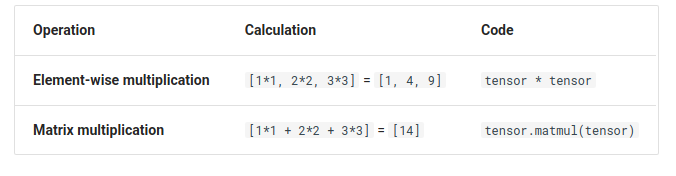

In [34]:
tensor = torch.tensor([1, 2, 3])

In [35]:
# Element-wise matrix multiplication
tensor * tensor

tensor([1, 4, 9])

In [36]:
# Matrix multiplication
torch.matmul(tensor, tensor)

tensor(14)

In [37]:
tensor@tensor

tensor(14)

### One of the most common errors in deep learning (shape errors)

In [38]:
# Shapes need to be in the right way  
tensor_A = torch.tensor([[1, 2],
                         [3, 4],
                         [5, 6]], dtype=torch.float32)

tensor_B = torch.tensor([[7, 10],
                         [8, 11], 
                         [9, 12]], dtype=torch.float32)

# torch.matmul(tensor_A, tensor_B) # (this will error)

In [39]:
# View tensor_A and tensor_B
print(tensor_A)
print(tensor_B)
print(tensor_A.shape)
print(tensor_B.shape)

tensor([[1., 2.],
        [3., 4.],
        [5., 6.]])
tensor([[ 7., 10.],
        [ 8., 11.],
        [ 9., 12.]])
torch.Size([3, 2])
torch.Size([3, 2])


In [40]:
# View tensor_A and tensor_B.T
print(tensor_A)
print(tensor_B.T)

tensor([[1., 2.],
        [3., 4.],
        [5., 6.]])
tensor([[ 7.,  8.,  9.],
        [10., 11., 12.]])


In [41]:
# The operation works when tensor_B is transposed
print(f"Original shapes: tensor_A = {tensor_A.shape}, tensor_B = {tensor_B.shape}\n")
print(f"New shapes: tensor_A = {tensor_A.shape} (same as above), tensor_B.T = {tensor_B.T.shape}\n")
print(f"Multiplying: {tensor_A.shape} * {tensor_B.T.shape} <- inner dimensions match\n")
print("Output:\n")
output = torch.matmul(tensor_A, tensor_B.T)
print(output) 
print(f"\nOutput shape: {output.shape}")

Original shapes: tensor_A = torch.Size([3, 2]), tensor_B = torch.Size([3, 2])

New shapes: tensor_A = torch.Size([3, 2]) (same as above), tensor_B.T = torch.Size([2, 3])

Multiplying: torch.Size([3, 2]) * torch.Size([2, 3]) <- inner dimensions match

Output:

tensor([[ 27.,  30.,  33.],
        [ 61.,  68.,  75.],
        [ 95., 106., 117.]])

Output shape: torch.Size([3, 3])


In [42]:
# torch.mm is a shortcut for matmul
torch.mm(tensor_A, tensor_B.T)

tensor([[ 27.,  30.,  33.],
        [ 61.,  68.,  75.],
        [ 95., 106., 117.]])

In [43]:
tensor_C = torch.rand((3,3))

In [44]:
# Since the linear layer starts with a random weights matrix, let's make it reproducible (more on this later)
torch.manual_seed(42)
# This uses matrix multiplication
linear = torch.nn.Linear(in_features=3, # in_features = matches inner dimension of input 
                         out_features=6) # out_features = describes outer value 
x = tensor_C
output = linear(x)
print(f"Input shape: {x.shape}\n")
print(f"Output:\n{output}\n\nOutput shape: {output.shape}")

Input shape: torch.Size([3, 3])

Output:
tensor([[ 0.3478,  0.2886,  0.1253,  0.2861,  0.1213,  0.8189],
        [ 0.4197,  0.5005, -0.2527, -0.0701,  0.1776,  0.6231],
        [ 0.4982,  0.5960,  0.1358,  0.0863,  0.4200,  0.7841]],
       grad_fn=<AddmmBackward0>)

Output shape: torch.Size([3, 6])


### Finding the min, max, mean, sum, etc (aggregation)

In [45]:
# Create a tensor
x = torch.arange(0, 100, 10)
x

tensor([ 0, 10, 20, 30, 40, 50, 60, 70, 80, 90])

In [46]:
print(f"Minimum: {x.min()}")
print(f"Maximum: {x.max()}")
# print(f"Mean: {x.mean()}") # this will error
print(f"Mean: {x.type(torch.float32).mean()}") # won't work without float datatype
print(f"Sum: {x.sum()}")

Minimum: 0
Maximum: 90
Mean: 45.0
Sum: 450


#### We can also do the same as above with torch methods.

In [47]:
torch.max(x), torch.min(x), torch.mean(x.type(torch.float32)), torch.sum(x)

(tensor(90), tensor(0), tensor(45.), tensor(450))

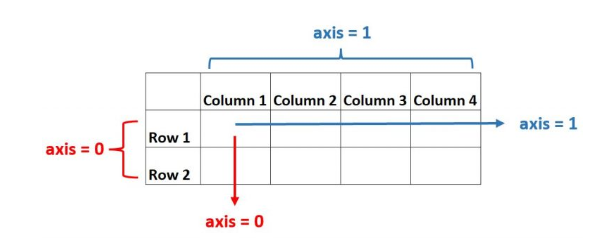

In [48]:
x = torch.tensor([
    [1, 2],
    [3, 4],
    [5, 6]
])

In [49]:
torch.max(x, axis=0)
# torch.max(x, axis=1)
# torch.max(x, axis=0).values
# torch.max(x, axis=0).indices
# torch.max(x, axis=1).values 
# torch.max(x, axis=1).indices

torch.return_types.max(
values=tensor([5, 6]),
indices=tensor([2, 2]))

#### Positional min/max

In [50]:
# Create a tensor
tensor = torch.arange(10, 100, 10)
print(f"Tensor: {tensor}")

# Returns index of max and min values
print(f"Index where max value occurs: {tensor.argmax()}")
print(f"Index where min value occurs: {tensor.argmin()}")

Tensor: tensor([10, 20, 30, 40, 50, 60, 70, 80, 90])
Index where max value occurs: 8
Index where min value occurs: 0


#### Change tensor datatype

In [51]:
# Create a tensor and check its datatype
tensor = torch.arange(10., 100., 10.)
tensor.dtype

torch.float32

In [52]:
# Change the datatype of a tensor float32
tensor = tensor.type(torch.float32)
tensor.dtype

torch.float32

In [53]:
# Create an int8 tensor
tensor = torch.tensor([1, 2, 3], dtype=torch.int8)
tensor.dtype

torch.int8

### Reshaping, stacking, squeezing and unsqueezing

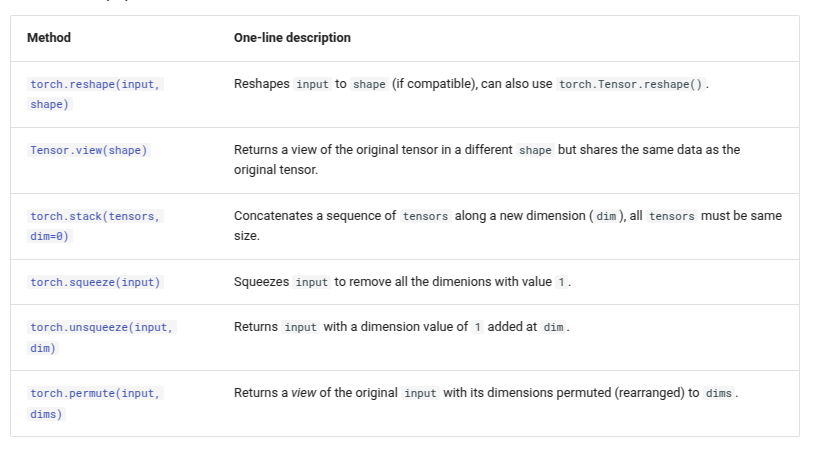

In [54]:
# Create a tensor
x = torch.arange(1., 8.)
x, x.shape

(tensor([1., 2., 3., 4., 5., 6., 7.]), torch.Size([7]))

In [55]:
# Add an extra dimension
x_reshaped = x.reshape(1, 7)
x_reshaped, x_reshaped.shape

(tensor([[1., 2., 3., 4., 5., 6., 7.]]), torch.Size([1, 7]))

In [56]:
# Change view (keeps same data as original but changes view)
# See more: https://stackoverflow.com/a/54507446/7900723
z = x.view(1, 7)
z, z.shape

(tensor([[1., 2., 3., 4., 5., 6., 7.]]), torch.Size([1, 7]))

#### changing the view changes the original tensor too.

In [57]:
# Changing z changes x
z[:, 0] = 5
z, x

(tensor([[5., 2., 3., 4., 5., 6., 7.]]), tensor([5., 2., 3., 4., 5., 6., 7.]))

In [58]:
# Stack tensors on top of each other
x_stacked = torch.stack([x, x, x, x], dim=0) # try changing dim to dim=1 and see what happens
x_stacked

tensor([[5., 2., 3., 4., 5., 6., 7.],
        [5., 2., 3., 4., 5., 6., 7.],
        [5., 2., 3., 4., 5., 6., 7.],
        [5., 2., 3., 4., 5., 6., 7.]])

In [59]:
# Stack tensors on top of each other
x_stacked = torch.stack([x, x, x, x], dim=1) # stack horizontally
x_stacked

tensor([[5., 5., 5., 5.],
        [2., 2., 2., 2.],
        [3., 3., 3., 3.],
        [4., 4., 4., 4.],
        [5., 5., 5., 5.],
        [6., 6., 6., 6.],
        [7., 7., 7., 7.]])

#### Removing Single Dimensions with `torch.squeeze()`

In [60]:
print(f"Previous tensor: {x_reshaped}")
print(f"Previous shape: {x_reshaped.shape}")

# Remove extra dimension from x_reshaped
x_squeezed = x_reshaped.squeeze()
print(f"\nNew tensor: {x_squeezed}")
print(f"New shape: {x_squeezed.shape}")

Previous tensor: tensor([[5., 2., 3., 4., 5., 6., 7.]])
Previous shape: torch.Size([1, 7])

New tensor: tensor([5., 2., 3., 4., 5., 6., 7.])
New shape: torch.Size([7])


#### Adding dimensions with `torch.unsqueeze()`

`torch.unsqueeze()` adds a dimension of size 1 at the specified index position. This is the opposite operation of `torch.squeeze()`.

In [61]:
x = torch.tensor([1, 2, 3])    # shape: [3]

x_unsqueezed = x.unsqueeze(1) # shape: [3, 1]
x_unsqueezed.shape

torch.Size([3, 1])

In [62]:
# Create tensor with specific shape
x_original = torch.rand(size=(4, 224, 3))

# Permute the original tensor to rearrange the axis order
x_permuted = x_original.permute(2, 0, 1) # shifts axis 0->1, 1->2, 2->0

print(f"Previous shape: {x_original.shape}")
print(f"New shape: {x_permuted.shape}")

Previous shape: torch.Size([4, 224, 3])
New shape: torch.Size([3, 4, 224])


Because permuting returns a view (shares the same data as the original), the values in the permuted tensor will be the same as the original tensor and if you change the values in the view, it will change the values of the original.

### Indexing (selecting data from tensors)

In [63]:
x = torch.arange(1, 10).reshape(1, 3, 3)
x, x.shape

(tensor([[[1, 2, 3],
          [4, 5, 6],
          [7, 8, 9]]]),
 torch.Size([1, 3, 3]))

Indexing values in multi-dimensional arrays follow the order:  
**Outer dimension → Inner dimension**  

This means that when using square brackets (`[]`), the first index refers to the outermost dimension, the second index refers to the next inner dimension, and so on.




### General Rule:
For an array with shape `(d1, d2, d3, ...)`:
- `arr[i]` → Selects the `i`-th element along the first dimension (`d1`).
- `arr[i, j]` → Selects the `j`-th element along the second dimension (`d2`) of the selected `i`-th element.
- `arr[i, j, k]` → Selects the `k`-th element along the third dimension (`d3`) of the selected `arr[i, j]`.


In [64]:
# Let's index bracket by bracket
print(f"First square bracket:\n{x[0]}") 
print(f"Second square bracket: {x[0][0]}") 
print(f"Third square bracket: {x[0][0][0]}")

First square bracket:
tensor([[1, 2, 3],
        [4, 5, 6],
        [7, 8, 9]])
Second square bracket: tensor([1, 2, 3])
Third square bracket: 1


In [65]:
x

tensor([[[1, 2, 3],
         [4, 5, 6],
         [7, 8, 9]]])

 we can also use : to specify "all values in this dimension" and then use a comma (,) to add another dimension

In [66]:
# Get all values of 0th dimension and the 0 index of 1st dimension
x[:, 1]

tensor([[4, 5, 6]])

In [67]:
x[:, 2, 1]

tensor([8])

In [68]:
x[:, :, 0]

tensor([[1, 4, 7]])

In [69]:
x[:, 1, 1]

tensor([5])

In [70]:
# Get index 0 of 0th and 1st dimension and all values of 2nd dimension 
x[0, 0, :] # same as x[0][0]

tensor([1, 2, 3])

### Reproducibility (trying to take the random out of random)

In [71]:
# Create two random tensors
random_tensor_A = torch.rand(3, 4)
random_tensor_B = torch.rand(3, 4)

print(f"Tensor A:\n{random_tensor_A}\n")
print(f"Tensor B:\n{random_tensor_B}\n")
print(f"Does Tensor A equal Tensor B? (anywhere)")
random_tensor_A == random_tensor_B

Tensor A:
tensor([[0.5797, 0.9968, 0.9606, 0.6824],
        [0.8679, 0.9861, 0.6417, 0.6668],
        [0.5650, 0.9427, 0.9295, 0.2649]])

Tensor B:
tensor([[0.4794, 0.2481, 0.6794, 0.0155],
        [0.6769, 0.3628, 0.6813, 0.6561],
        [0.2512, 0.7594, 0.7123, 0.0750]])

Does Tensor A equal Tensor B? (anywhere)


tensor([[False, False, False, False],
        [False, False, False, False],
        [False, False, False, False]])

In [72]:
import random

# # Set the random seed
RANDOM_SEED=42 # try changing this to different values and see what happens to the numbers below
torch.manual_seed(seed=RANDOM_SEED) 
random_tensor_C = torch.rand(3, 4)

# Have to reset the seed every time a new rand() is called 
# Without this, tensor_D would be different to tensor_C 
torch.random.manual_seed(seed=RANDOM_SEED) # try commenting this line out and seeing what happens
random_tensor_D = torch.rand(3, 4)

print(f"Tensor C:\n{random_tensor_C}\n")
print(f"Tensor D:\n{random_tensor_D}\n")
print(f"Does Tensor C equal Tensor D? (anywhere)")
random_tensor_C == random_tensor_D

Tensor C:
tensor([[0.8823, 0.9150, 0.3829, 0.9593],
        [0.3904, 0.6009, 0.2566, 0.7936],
        [0.9408, 0.1332, 0.9346, 0.5936]])

Tensor D:
tensor([[0.8823, 0.9150, 0.3829, 0.9593],
        [0.3904, 0.6009, 0.2566, 0.7936],
        [0.9408, 0.1332, 0.9346, 0.5936]])

Does Tensor C equal Tensor D? (anywhere)


tensor([[True, True, True, True],
        [True, True, True, True],
        [True, True, True, True]])